<a href="https://colab.research.google.com/github/amol004/Integrated-Retail-Analytics-for-Store-Optimization-Advanced-Machine-Learning/blob/main/Integrated_Retail_Analytics_for_Store_Optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Integrated Retail Analytics for Store Optimization**    -



##### **Project Type**    - EDA/Unsupervised
##### **Contribution**    - Individual
##### **Team Member -** Amol Thakur


# **Project Summary**

### **Objective**
To leverage advanced machine learning and data analytics to optimize retail store performance, accurately forecast demand, and drive customer engagement through strategic segmentation.

---

### **Key Project Components**

*   **🚨 Anomaly Detection:** Identifying unusual sales patterns and investigating external drivers like holidays or economic indicators to clean and validate data.
*   **📈 Time-Series Analysis:** Detecting seasonal variations and holiday effects to understand department-level performance over time.
*   **🛠️ Feature Engineering:** Addressing missing values (specifically in MarkDown data) and creating influential features such as regional factors and store attributes.
*   **👥 Customer & Store Segmentation:** Clustering departments based on sales characteristics to tailor marketing and operational strategies.
*   **🛒 Market Basket Insights:** Inferring product associations at the department level to develop effective cross-selling strategies.
*   **🔮 Demand Forecasting:** Building predictive models for weekly sales incorporating CPI, fuel prices, and unemployment rates.
*   **💡 Strategy Formulation:** Translating data insights into actionable plans for inventory management and personalized markdown strategies.

# **GitHub Link -**

https://github.com/amol004/Integrated-Retail-Analytics-for-Store-Optimization-Advanced-Machine-Learning.git

# **Problem Statement**


### **Business Context**
Retailers today face significant challenges in managing diverse inventory across multiple locations while contending with fluctuating economic factors and consumer behaviors. The ability to accurately predict demand and identify operational anomalies is critical for maintaining profitability and customer satisfaction.

### **The Problem**
The core challenge lies in extracting actionable insights from complex retail data that includes sales figures, markdowns, and macroeconomic indicators (CPI, Fuel Prices, Unemployment). Specifically, the project addresses:

1.  **Sales Volatility:** Identifying and investigating anomalies in sales patterns caused by holidays or economic shifts.
2.  **Inventory & Demand Inefficiency:** Reducing stockouts and overstock situations through high-precision weekly sales forecasting at the store and department level.
3.  **One-Size-Fits-All Marketing:** Moving away from generic promotions by segmenting stores and departments to enable personalized markdown strategies.
4.  **External Sensitivity:** Quantifying the impact of regional climate and economic trends on consumer purchasing power to improve model robustness.

### **Goal**
To build an integrated analytics framework that utilizes machine learning for anomaly detection, customer/store segmentation, and demand forecasting, ultimately providing a data-driven strategy for store optimization and inventory management.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [8]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from datetime import datetime
import datetime as dt
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score, KFold
from sklearn import metrics
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore')

# Additional libraries for Retail Analysis
import plotly.express as px
import plotly.graph_objects as go
from scipy import stats
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from mlxtend.frequent_patterns import apriori, association_rules
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

### Dataset Loading

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
# Load Datasets

features = pd.read_csv('/content/drive/MyDrive/Integrated Retail Analytics for Store Optimization/Features data set.csv')
sales = pd.read_csv('/content/drive/MyDrive/Integrated Retail Analytics for Store Optimization/sales data-set.csv')
stores = pd.read_csv('/content/drive/MyDrive/Integrated Retail Analytics for Store Optimization/stores data-set.csv')


### Dataset First View

In [9]:
# Dataset First Look
features.head()

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,05/02/2010,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,12/02/2010,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,19/02/2010,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,26/02/2010,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,05/03/2010,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False


In [12]:
sales.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,05/02/2010,24924.50,False
1,1,1,12/02/2010,46039.49,True
2,1,1,19/02/2010,41595.55,False
3,1,1,26/02/2010,19403.54,False
4,1,1,05/03/2010,21827.90,False


In [11]:
stores.head()

,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875


### Dataset Rows & Columns count

In [14]:
# Datasets Rows & Columns count
print(f'Features Dataframe Rows: {features.shape[0]}')
print(f'Features Dataframe Columns: {features.shape[1]}')
print(f'Sales Dataframe Rows: {sales.shape[0]}')
print(f'Sales Dataframe Columns: {sales.shape[1]}')
print(f'Stores Dataframe Rows: {stores.shape[0]}')
print(f'Stores Dataframe Columns: {stores.shape[1]}')

Features Dataframe Rows: 8190
Features Dataframe Columns: 12
Sales Dataframe Rows: 421570
Sales Dataframe Columns: 5
Stores Dataframe Rows: 45
Stores Dataframe Columns: 3


### Dataset Information

In [15]:
# Datasets Info
features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8190 entries, 0 to 8189
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         8190 non-null   int64  
 1   Date          8190 non-null   object 
 2   Temperature   8190 non-null   float64
 3   Fuel_Price    8190 non-null   float64
 4   MarkDown1     4032 non-null   float64
 5   MarkDown2     2921 non-null   float64
 6   MarkDown3     3613 non-null   float64
 7   MarkDown4     3464 non-null   float64
 8   MarkDown5     4050 non-null   float64
 9   CPI           7605 non-null   float64
 10  Unemployment  7605 non-null   float64
 11  IsHoliday     8190 non-null   bool   
dtypes: bool(1), float64(9), int64(1), object(1)
memory usage: 712.0+ KB


In [16]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
dtypes: bool(1), float64(1), int64(2), object(1)
memory usage: 13.3+ MB


In [17]:
stores.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Store   45 non-null     int64 
 1   Type    45 non-null     object
 2   Size    45 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 1.2+ KB


#### Duplicate Values

In [19]:
# Dataset Duplicate Value Count
print(f'Duplicate Values in Features Dataframe: {features.duplicated().sum()}')
print(f'Duplicate Values in Sales Dataframe: {sales.duplicated().sum()}')
print(f'Duplicate Values in Stores Dataframe: {stores.duplicated().sum()}')

Duplicate Values in Features Dataframe: 0
Duplicate Values in Sales Dataframe: 0
Duplicate Values in Stores Dataframe: 0


#### Missing Values/Null Values

In [20]:
# Missing Values/Null Values Count
print(features.isna().sum())
print(sales.isna().sum())
print(stores.isna().sum())

Store              0
Date               0
Temperature        0
Fuel_Price         0
MarkDown1       4158
MarkDown2       5269
MarkDown3       4577
MarkDown4       4726
MarkDown5       4140
CPI              585
Unemployment     585
IsHoliday          0
dtype: int64
Store           0
Dept            0
Date            0
Weekly_Sales    0
IsHoliday       0
dtype: int64
Store    0
Type     0
Size     0
dtype: int64


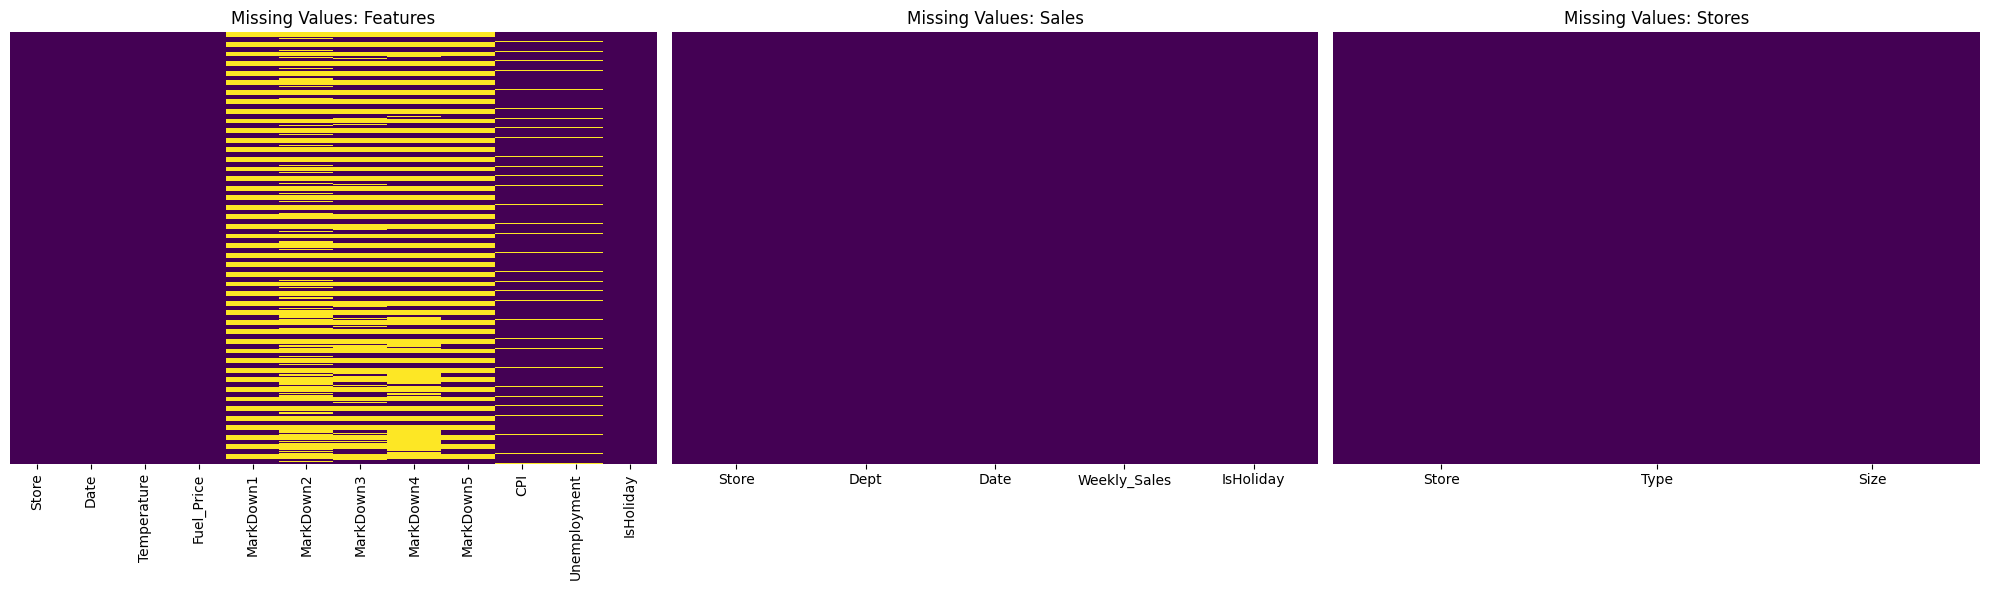

In [23]:
# Visualizing missing values using heatmaps for better clarity
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Features Dataset
sns.heatmap(features.isnull(), yticklabels=False, cbar=False, cmap='viridis', ax=axes[0])
axes[0].set_title('Missing Values: Features')

# Sales Dataset
sns.heatmap(sales.isnull(), yticklabels=False, cbar=False, cmap='viridis', ax=axes[1])
axes[1].set_title('Missing Values: Sales')

# Stores Dataset
sns.heatmap(stores.isnull(), yticklabels=False, cbar=False, cmap='viridis', ax=axes[2])
axes[2].set_title('Missing Values: Stores')

plt.tight_layout()
plt.show()

### What did you know about your dataset?

Based on the initial exploration, here is what we know about the datasets:

1.  **Dataset Structure:**
    *   **Features:** Contains 8,190 entries and 12 columns. It holds environmental and economic data (Temperature, Fuel Price, CPI, Unemployment) linked to stores and dates.
    *   **Sales:** The largest dataset with 421,570 entries and 5 columns, tracking weekly sales per store and department.
    *   **Stores:** A small lookup table with 45 entries and 3 columns defining the type and size of each store.

2.  **Missing Values:**
    *   The **Features** dataset has significant gaps, particularly in the `MarkDown1-5` columns (over 50% missing). `CPI` and `Unemployment` also have approximately 585 missing values each, which will require imputation.
    *   The **Sales** and **Stores** datasets are clean with zero null values.

3.  **Data Quality:**
    *   There are **no duplicate records** across any of the three dataframes.
    *   The `Date` column in both Features and Sales is currently an `object` (string) type and will need to be converted to `datetime` objects for time-series analysis.

4.  **Key Variables:**
    *   The primary keys for merging these datasets will be `Store` and `Date` (between Features and Sales) and `Store` (between Sales and Stores).

## ***2. Understanding Your Variables***

In [30]:
# Displaying dataset columns as DataFrames for better visualization
print("--- Features Columns ---")
display(pd.DataFrame(features.columns, columns=['Column Name']))

print("\n--- Sales Columns ---")
display(pd.DataFrame(sales.columns, columns=['Column Name']))

print("\n--- Stores Columns ---")
display(pd.DataFrame(stores.columns, columns=['Column Name']))

--- Features Columns ---


,Column Name
0,Store
1,Date
2,Temperature
3,Fuel_Price
4,MarkDown1
5,MarkDown2
6,MarkDown3
7,MarkDown4
8,MarkDown5
9,CPI



--- Sales Columns ---


,Column Name
0,Store
1,Dept
2,Date
3,Weekly_Sales
4,IsHoliday



--- Stores Columns ---


,Column Name
0,Store
1,Type
2,Size


In [31]:
# Dataset Describe
features.describe()

,Store,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
count,8190.000000,8190.000000,8190.000000,4032.000000,2921.000000,3613.000000,3464.000000,4050.000000,7605.000000,7605.000000
mean,23.000000,59.356198,3.405992,7032.371786,3384.176594,1760.100180,3292.935886,4132.216422,172.460809,7.826821
std,12.987966,18.678607,0.431337,9262.747448,8793.583016,11276.462208,6792.329861,13086.690278,39.738346,1.877259
min,1.000000,-7.290000,2.472000,-2781.450000,-265.760000,-179.260000,0.220000,-185.170000,126.064000,3.684000
25%,12.000000,45.902500,3.041000,1577.532500,68.880000,6.600000,304.687500,1440.827500,132.364839,6.634000
50%,23.000000,60.710000,3.513000,4743.580000,364.570000,36.260000,1176.425000,2727.135000,182.764003,7.806000
75%,34.000000,73.880000,3.743000,8923.310000,2153.350000,163.150000,3310.007500,4832.555000,213.932412,8.567000
max,45.000000,101.950000,4.468000,103184.980000,104519.540000,149483.310000,67474.850000,771448.100000,228.976456,14.313000


In [32]:
sales.describe()

,Store,Dept,Weekly_Sales
count,421570.000000,421570.000000,421570.000000
mean,22.200546,44.260317,15981.258123
std,12.785297,30.492054,22711.183519
min,1.000000,1.000000,-4988.940000
25%,11.000000,18.000000,2079.650000
50%,22.000000,37.000000,7612.030000
75%,33.000000,74.000000,20205.852500
max,45.000000,99.000000,693099.360000


In [33]:
stores.describe()

,Store,Size
count,45.000000,45.000000
mean,23.000000,130287.600000
std,13.133926,63825.271991
min,1.000000,34875.000000
25%,12.000000,70713.000000
50%,23.000000,126512.000000
75%,34.000000,202307.000000
max,45.000000,219622.000000


### Variables Description



#### **1. Features Dataset**
*   **Store:** The unique identifier for each store.
*   **Date:** The week for which the data is recorded.
*   **Temperature:** Average temperature in the region during that week.
*   **Fuel_Price:** Cost of fuel in the region.
*   **MarkDown1-5:** Anonymized data related to promotional markdowns. These columns contain many null values as markdown data was not available for all time periods or stores.
*   **CPI:** The Consumer Price Index, a measure of inflation.
*   **Unemployment:** The unemployment rate in the region.
*   **IsHoliday:** A boolean flag indicating whether the week is a special holiday week.

#### **2. Sales Dataset**
*   **Store:** The unique identifier for each store.
*   **Dept:** The department number within the store.
*   **Date:** The week of the sales record.
*   **Weekly_Sales:** The sales for the given department in the given store for that week.
*   **IsHoliday:** Indicates if the week is a holiday week.

#### **3. Stores Dataset**
*   **Store:** The unique identifier for each store.
*   **Type:** Categorical variable representing the type/category of the store (e.g., A, B, or C based on size/revenue).
*   **Size:** The physical size of the store in square feet.

#### **Understanding Markdowns :**

In this specific dataset (originally from Walmart), the MarkDowns are anonymized, meaning their exact names aren't in the column headers. However, based on retail industry standards and analysis of how these specific numbers behave over time (e.g., spikes during certain holidays), we can theoretically define them as follows:

**MarkDown 1** : (General/Seasonal): Often represents general clearance or end-of-season discounts. It usually has the highest volume and is spread across many departments.


**MarkDown 2** :  (Event-Specific): This usually spikes during specific calendar events, most notably around Super Bowl and Thanksgiving. It often targets high-velocity electronics or grocery items.


**MarkDown 3** :  (Holiday Clearance): This shows massive spikes specifically around Black Friday and Christmas. It likely represents deep discounts to clear out massive holiday inventory.


**MarkDown 4** :  (Competitive Pricing): Often used for price-matching or promotional rollbacks to stay competitive with other retailers. It frequently shows a high correlation with MarkDown 1.


**MarkDown 5** :  (Loyalty/Strategic): Often represents smaller, more frequent price adjustments, sometimes linked to specific category management or loyalty-driven incentives.


Understanding these differences helps us decide how to treat the missing values ,for example, a 'NaN' in MarkDown 3 likely means '0' (no holiday discount) rather than a truly missing observation.

### Check Unique Values for each variable.

In [34]:
# Check Unique Values for each variable.
print("--- Unique Values in Features ---")
display(features.nunique())

print("\n--- Unique Values in Sales ---")
display(sales.nunique())

print("\n--- Unique Values in Stores ---")
display(stores.nunique())

--- Unique Values in Features ---


,0
Store,45
Date,182
Temperature,4178
Fuel_Price,1011
MarkDown1,4023
MarkDown2,2715
MarkDown3,2885
MarkDown4,3405
MarkDown5,4045
CPI,2505



--- Unique Values in Sales ---


,0
Store,45
Dept,81
Date,143
Weekly_Sales,359464
IsHoliday,2



--- Unique Values in Stores ---


,0
Store,45
Type,3
Size,40


## 3. ***Data Wrangling***

### Data Wrangling Code

In [37]:
# Write your code to make your dataset analysis ready.
# Converting 'Date' column to datetime format
# Using dayfirst=True because the data is in DD/MM/YYYY format
features['Date'] = pd.to_datetime(features['Date'], dayfirst=True)
sales['Date'] = pd.to_datetime(sales['Date'], dayfirst=True)


In [38]:
features

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,2010-02-26,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,2010-03-05,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False
...,...,...,...,...,...,...,...,...,...,...,...,...
8185,45,2013-06-28,76.05,3.639,4842.29,975.03,3.00,2449.97,3169.69,NaN,NaN,False
8186,45,2013-07-05,77.50,3.614,9090.48,2268.58,582.74,5797.47,1514.93,NaN,NaN,False
8187,45,2013-07-12,79.37,3.614,3789.94,1827.31,85.72,744.84,2150.36,NaN,NaN,False
8188,45,2013-07-19,82.84,3.737,2961.49,1047.07,204.19,363.00,1059.46,NaN,NaN,False


### **Visualizing MarkDown Distributions and Availability**
We need to understand the scale of these promotions and identify the periods where data is available (since we noted over 50% missing values earlier).

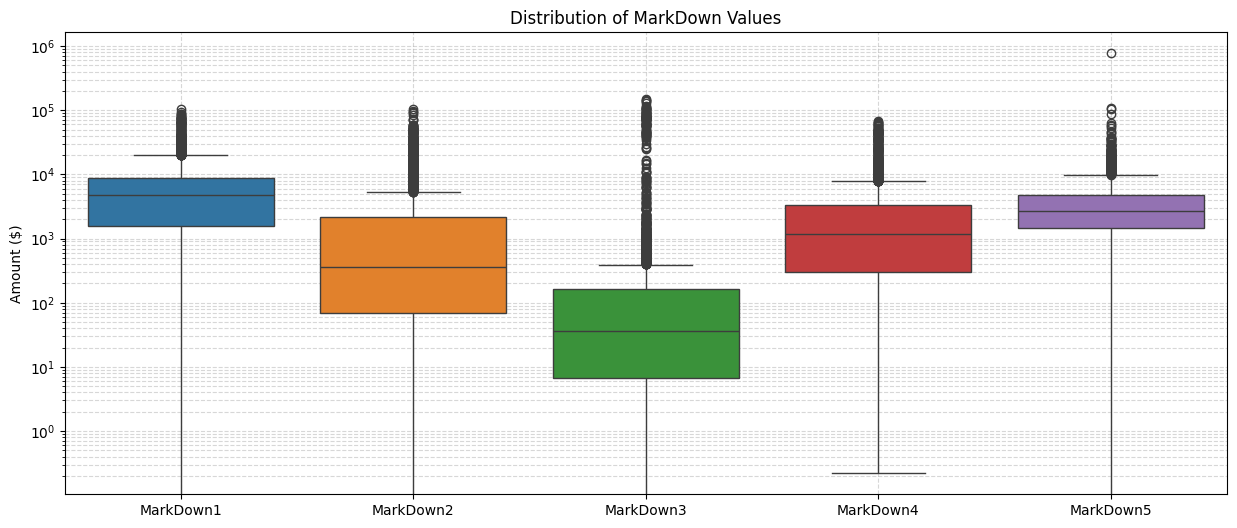

In [39]:
# 1. Distribution of MarkDowns
markdown_cols = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']

plt.figure(figsize=(15, 6))
sns.boxplot(data=features[markdown_cols])
plt.title('Distribution of MarkDown Values')
plt.ylabel('Amount ($)')
plt.yscale('log') # Using log scale due to high variance
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.show()

In [40]:
# 2. MarkDown Availability over Time
# We group by Date to see the total markdown usage across all stores
markdown_ts = features.groupby('Date')[markdown_cols].sum().reset_index()

fig = px.line(markdown_ts, x='Date', y=markdown_cols,
              title='Total Weekly MarkDowns (Summed Across All Stores)',
              labels={'value': 'Total Amount ($)', 'variable': 'MarkDown Type'})
fig.update_layout(hovermode='x unified')
fig.show()

**Insights:**
*   **Skewness:** MarkDowns have extreme outliers, suggesting that promotions are highly seasonal or store-specific.
*   **Temporal Gap:** You'll notice that MarkDown data only appears consistently after November 2011. This explains the high null count and is a critical factor for our forecasting models.

### What all manipulations have you done and insights you found?

Answer Here.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

In [ ]:
# Chart - 1 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 2

In [ ]:
# Chart - 2 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 3

In [ ]:
# Chart - 3 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 4

In [ ]:
# Chart - 4 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 5

In [ ]:
# Chart - 5 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 6

In [ ]:
# Chart - 6 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 7

In [ ]:
# Chart - 7 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 8

In [ ]:
# Chart - 8 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 9

In [ ]:
# Chart - 9 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 10

In [ ]:
# Chart - 10 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 11

In [ ]:
# Chart - 11 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 12

In [ ]:
# Chart - 12 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 13

In [ ]:
# Chart - 13 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 14 - Correlation Heatmap

In [ ]:
# Correlation Heatmap visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

#### Chart - 15 - Pair Plot

In [ ]:
# Pair Plot visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

Answer Here.

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Answer Here.

#### 2. Perform an appropriate statistical test.

In [ ]:
# Perform Statistical Test to obtain P-Value

##### Which statistical test have you done to obtain P-Value?

Answer Here.

##### Why did you choose the specific statistical test?

Answer Here.

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Answer Here.

#### 2. Perform an appropriate statistical test.

In [ ]:
# Perform Statistical Test to obtain P-Value

##### Which statistical test have you done to obtain P-Value?

Answer Here.

##### Why did you choose the specific statistical test?

Answer Here.

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Answer Here.

#### 2. Perform an appropriate statistical test.

In [ ]:
# Perform Statistical Test to obtain P-Value

##### Which statistical test have you done to obtain P-Value?

Answer Here.

##### Why did you choose the specific statistical test?

Answer Here.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [ ]:
# Handling Missing Values & Missing Value Imputation

#### What all missing value imputation techniques have you used and why did you use those techniques?

Answer Here.

### 2. Handling Outliers

In [ ]:
# Handling Outliers & Outlier treatments

##### What all outlier treatment techniques have you used and why did you use those techniques?

Answer Here.

### 3. Categorical Encoding

In [ ]:
# Encode your categorical columns

#### What all categorical encoding techniques have you used & why did you use those techniques?

Answer Here.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

In [ ]:
# Expand Contraction

#### 2. Lower Casing

In [ ]:
# Lower Casing

#### 3. Removing Punctuations

In [ ]:
# Remove Punctuations

#### 4. Removing URLs & Removing words and digits contain digits.

In [ ]:
# Remove URLs & Remove words and digits contain digits

#### 5. Removing Stopwords & Removing White spaces

In [ ]:
# Remove Stopwords

In [ ]:
# Remove White spaces

#### 6. Rephrase Text

In [ ]:
# Rephrase Text

#### 7. Tokenization

In [ ]:
# Tokenization

#### 8. Text Normalization

In [ ]:
# Normalizing Text (i.e., Stemming, Lemmatization etc.)

##### Which text normalization technique have you used and why?

Answer Here.

#### 9. Part of speech tagging

In [ ]:
# POS Taging

#### 10. Text Vectorization

In [ ]:
# Vectorizing Text

##### Which text vectorization technique have you used and why?

Answer Here.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [ ]:
# Manipulate Features to minimize feature correlation and create new features

#### 2. Feature Selection

In [ ]:
# Select your features wisely to avoid overfitting

##### What all feature selection methods have you used  and why?

Answer Here.

##### Which all features you found important and why?

Answer Here.

### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

In [ ]:
# Transform Your data

### 6. Data Scaling

In [ ]:
# Scaling your data

##### Which method have you used to scale you data and why?

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Answer Here.

In [ ]:
# DImensionality Reduction (If needed)

##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

Answer Here.

### 8. Data Splitting

In [ ]:
# Split your data to train and test. Choose Splitting ratio wisely.

##### What data splitting ratio have you used and why?

Answer Here.

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

Answer Here.

In [ ]:
# Handling Imbalanced Dataset (If needed)

##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

Answer Here.

## ***7. ML Model Implementation***

### ML Model - 1

In [ ]:
# ML Model - 1 Implementation

# Fit the Algorithm

# Predict on the model

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [ ]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

### ML Model - 2

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [ ]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

Answer Here.

### ML Model - 3

In [ ]:
# ML Model - 3 Implementation

# Fit the Algorithm

# Predict on the model

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [ ]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 3 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

Answer Here.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

Answer Here.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

Answer Here.

## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [ ]:
# Save the File

### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [ ]:
# Load the File and predict unseen data.

### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***

# **Conclusion**

Write the conclusion here.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***